<center>

# **Decision Trees and Ensemble Methods**

</center>



## Question 1: Brief Context

In this question, you will implement a **binary decision tree classifier** from scratch and apply it to the classic **Titanic** dataset. The target is `survived` (1 = survived, 0 = did not survive). You will: (i) prepare the data, (ii) split into train/test, (iii) implement and train your own tree, and (iv) evaluate performance with standard metrics. 

You **must** implement the decision tree **from scratch** (no scikit-learn tree). You may use `numpy`, `pandas`, `seaborn`, `matplotlib`, and `sklearn` **only** for utilities like `train_test_split` and metrics.


## Part A - Setup & Imports
**Guidance:** Use standard scientific Python tools. If a package is missing, install it in your environment before running the notebook.

- You will likely need: `numpy`, `pandas`, `seaborn`, `matplotlib`
- Utilities allowed from scikit-learn: `train_test_split`, `classification_report`, `confusion_matrix`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`
- **Do not** use scikit-learn decision tree implementations.

In [16]:
# TODO: Import the scientific Python stack you'll need.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Part B - Data Loading & Initial Glance 

**Tasks:**
1. Load the Titanic dataset from `seaborn` as `df`.  
2. Display the shape and first few rows.  
3. In the markdown cell below, briefly note which columns you expect to be useful for prediction and any columns you plan to exclude (IDs, duplicates, very sparse/free-text).  

---

### What are the features? 

- **Some potentially useful features:**  
  - `pclass`: Proxy for socioeconomic status.  
  - `sex`: Strong historical correlation with survival.  
  - `age`: Important demographic factor.  
  - `fare`: Reflects ticket cost and class.  
  - `embarked`: Port of embarkation, may indicate regional or class differences.  
  - `sibsp`: Number of siblings/spouses aboard, gives family context.  
  - `parch`: Number of parents/children aboard, captures family connections.  

- **Exclude these features: (duplicates, engineered, or sparse)**  
  - `class`, `who`, `adult_male`, `alone`: Engineered or redundant.  
  - `embark_town`: Duplicate of `embarked`.  
  - `alive`: Text duplicate of target `survived`.  
  - `deck`: Too sparse (many missing values).  


In [17]:
# explore dataset
df = sns.load_dataset("titanic")
print(df.head())
print(df.shape[0], df.shape[1])
df = df.drop(["class", "who", "adult_male" ,"deck", "embark_town", "alive", "alone"], axis=1)
print(df.shape[0], df.shape[1])

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
891 15
891 8


### Identify features that might have low predictive value. For each feature you mention, provide reasoning for why it may not be useful.

deck has many NaN values not worth keeping, embark_town, adult_male, alive, alone, class and who are redundant features.

## Part C - Data Tidying & Encoding
We tackle Part C in two simple passes so it is easier to follow: first, look at basic plots to see which columns clearly link to survival (strong correlations); second, keep only those useful columns and turn everything into numbers.

**Plain-language plan:**
1. **Part C.1 — Explore:** Plot survival rate for a few categorical columns (class, sex, embark, etc.). Circle or note the ones where the bars differ a lot — that means the feature carries a pattern your tree can learn.
2. **Part C.2 — Prep:** Based on those observations, build your feature matrix: keep pattern-rich columns, drop weak/noisy ones, clean missing values, and one-hot encode.

**Tips:**
- The target is `survived` (1 = yes, 0 = no). Keep it as the last column in any training dataframe.
- When you justify a feature, mention what you saw in the plot (e.g., "pclass=1 had much higher survival, so I kept it").
- Simple cleaning is fine: drop or fill NaNs with medians/modes, then encode categoricals with `pd.get_dummies`.
- Always keep `X` (features) and `y` (target) aligned.

**Deliverables:**
- Part C.1 plots + a short note on which columns look important.
- Part C.2 shapes for `X`/`y` and a head of the encoded dataframe.


### Part C.1 — Survival Rate by Categorical Features
Use this mini-exploration to spot obvious signals. For each categorical column, plot the average survival rate of its groups. If the bars look different, that column likely holds a strong clue.

Suggested columns (feel free to add others):
- `pclass` (1st/2nd/3rd class)
- `sex`
- `embarked`
- `alone`
- `adult_male`
- `fare`
- `who`

After plotting, jot down:
- Which columns show the clearest survival gaps.
- Which columns look flat/useless.
- One sentence on how this will guide the feature list in Part C.2.


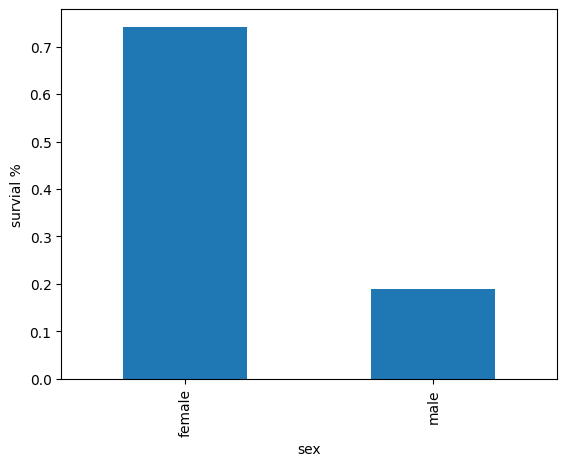

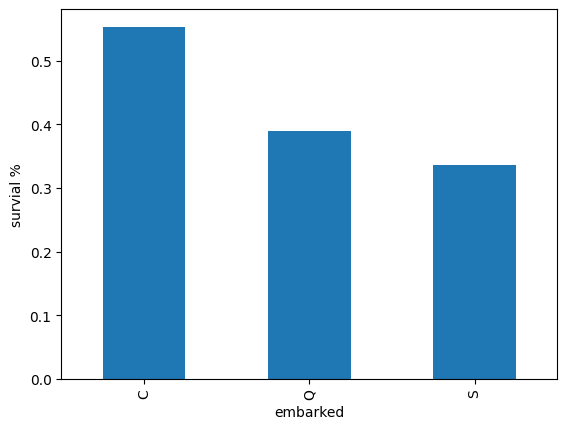

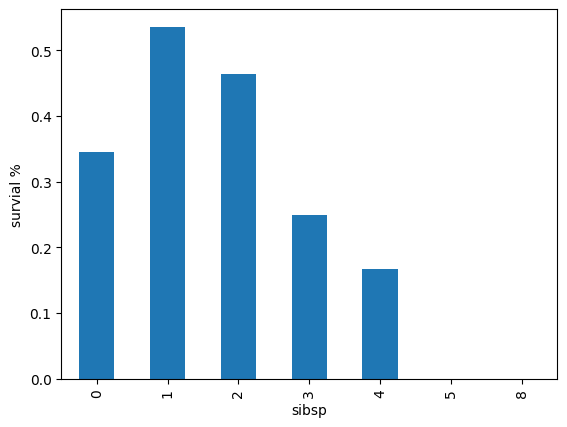

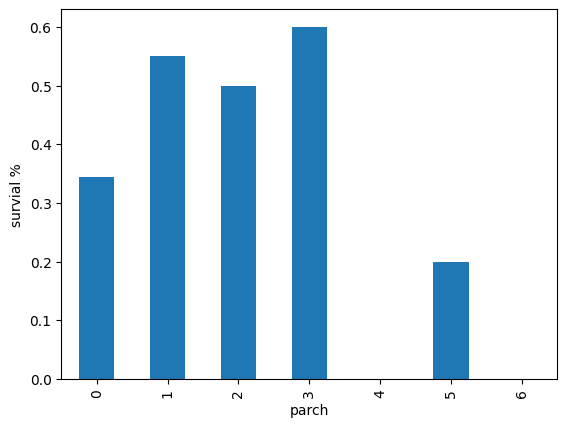

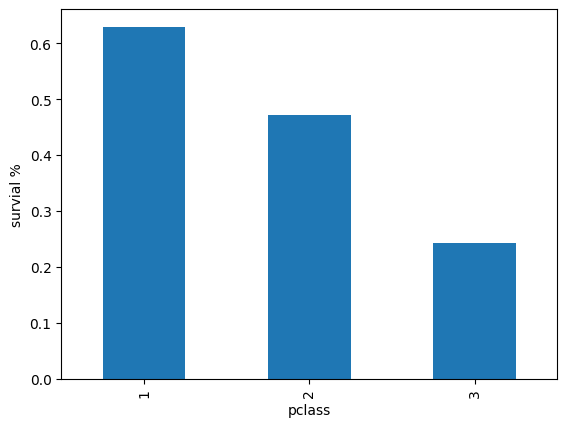

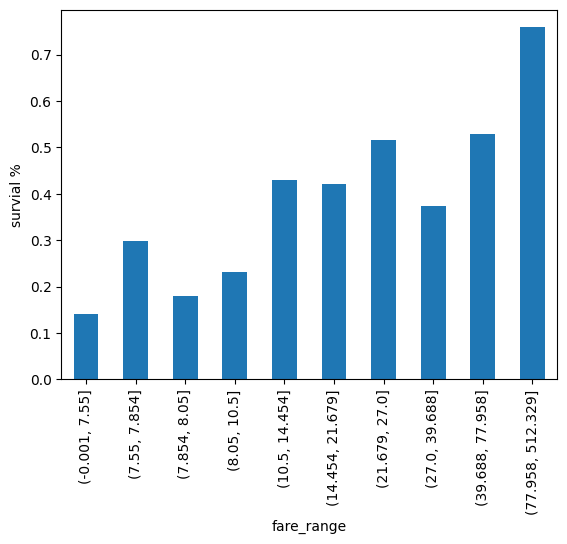

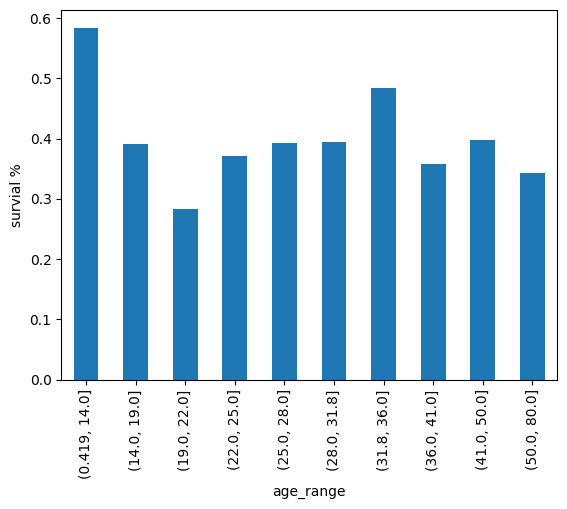

In [18]:
# TODO: Plot the mean survival rate for each categorical column listed above.
# Use df.groupby(col)['survived'].mean() and visualize comparable bars/subplots.
# Keep notes on which categories look the most/least promising.
plt.figure()
x = df.groupby("sex")["survived"].mean().plot(kind="bar") #looks most useful
plt.ylabel("survial %")
plt.show()
plt.figure()
x = df.groupby("embarked")["survived"].mean().plot(kind="bar") #looks useful
plt.ylabel("survial %")
plt.show()
plt.figure()
x = df.groupby("sibsp")["survived"].mean().plot(kind="bar") #looks useful
plt.ylabel("survial %")
plt.show()
plt.figure()
x = df.groupby("parch")["survived"].mean().plot(kind="bar") #looks useful
plt.ylabel("survial %")
plt.show()
plt.figure()
x = df.groupby("pclass")["survived"].mean().plot(kind="bar") #looks useful
plt.ylabel("survial %")
plt.show()
plt.figure()
df["fare_range"] = pd.qcut(df["fare"], q=10)
df.groupby("fare_range")["survived"].mean().plot(kind="bar") #looks very useful
plt.ylabel("survial %")
plt.show()
plt.figure()
df["age_range"] = pd.qcut(df["age"], q=10)
df.groupby("age_range")["survived"].mean().plot(kind="bar") #only 1 range looks useful rest not so much
plt.ylabel("survial %")
plt.show()

### Part C.2 — Choose Features & Encode
Now pick the columns that actually showed a survival pattern (clear correlation in Part C.1) and turn them into a tidy numeric matrix. When in doubt, keep the signal-rich basics (class, sex, age, siblings/spouses, parents/children, fare, embark).


**Guidance:**
- Target: `survived` (1 = survived, 0 = did not survive). Keep it as the final column for convenience.
- After reviewing the plots, pick base features such as `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, `alone`, etc., and justify exclusions (e.g., leakage, redundancy, missingness).
- Handle missing values with simple, clearly stated strategies (drop rows, fill with median/mode, etc.).
- Use a concise one-hot encoder (e.g., `pd.get_dummies`) to turn categorical columns into numeric indicators.
- Maintain aligned `X` (features) and `y` (target) indices.





In [19]:
# TODO: Build a cleaned feature matrix informed by Part C.1.
# 1) Select final feature_cols + target, 2) handle missing values, 3) one-hot encode categoricals (pd.get_dummies).
# Return aligned X (encoded features), y (target), and a simplified df_tree for the scratch tree.
#i am keeping all the ones above excpet the given ones that were confirmed extra or duplicates. i think the chosen ones here have enough of a relation to help determine survial.
df = df.dropna()
df_encoded = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=False)
y = df_encoded["survived"]
X = df_encoded.drop("survived", axis=1)

## Part D - Train/Test Split
**Guidance:**
- Use the sklearn library to perform an 80/20 split on your data, saving 20% of it for testing and using 80% of it for training your model. 

**Deliverables:** shapes and class balance check (optional mean of `y`).

In [20]:
# TODO: Implement an 80/20 train/test split using sklearn.
# Use sklearn.model_selection.train_test_split with test_size=0.2 and a fixed random_state
# to ensure deterministic shuffling.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8, test_size=0.2, random_state=1)
print(X_train.shape[0], X_train.shape[1])
print(X_test.shape[0], X_test.shape[1])
print(y_train.shape[0])
print(y_test.shape[0])
print(y.mean())


569 12
143 12
569
143
0.4044943820224719


## Part F - Decision Tree design from scratch
**You must implement the core logic.** Below is a suggested structure. You may alter method signatures, add helpers, and use a different internal design if you prefer, but keep responsibilities clear:

- `Node`: stores split info (`feature`, `threshold`), children (`left`, `right`), and for leaves, a `classifier` (majority class) or distribution.
- `DecisionTree`: orchestrates fitting (`fit`), recursive tree building (`make_tree`), traversal for predictions (`traverse_tree`, `predict`), splitting (`best_split`, `split`), and impurity calculations (`calculate_entropy`, `calculate_information_gain`).

**Policy:**
- Use **entropy** as the impurity measure and **information gain** for splits.
- Only **binary splits** of the form `feature <= threshold`.
- Stopping criteria (minimum): `max_depth` reached **or** min_samples remaining **or** pure node (all labels identical) **or** no valid split (info gain ≤ 0).

The code below is a **skeleton**. Fill in the `TODO` parts. 

**BONUS:**
- You may add extra helper functions, or you may change the given function signatures as needed. If you add any extra features which allow for interesting functionality / interesting analysis down the line (you will have to show the analysis as well) - you get bonus marks. This bonus will not exceed the total number of marks allotted for the assignment.

In [21]:
import numpy as np

class Node:
    def __init__(self, left=None, right=None, feature=None, threshold=None, classifier=None, num=None, element=None, depth=None):
        """Leaf nodes store a classifier label; internal nodes carry a feature+threshold."""
        self.left = left
        self.right = right
        self.feature = feature
        self.threshold = threshold
        self.classifier = classifier
        self.numelements = num
        self.elements = element
        self.depth = depth

    def is_leaf(self):
        """Convenience helper so you know when traversal should stop."""
        return self.classifier is not None

class DecisionTree:
    def __init__(self, max_depth=5, min_samples=2):
        """Store any hyperparameters you need (e.g., depth limit, feature indices)."""
        self.max_depth = max_depth
        self.root = None
        self.min_samples = min_samples

    def fit(self, Xy):
        """Build the tree recursively using the combined feature+label matrix."""
        used_cats = set()
        self.root = self._make_tree(Xy, depth=1, used=used_cats)

    def predict(self, X):
        """Traverse the learned tree row by row to produce class predictions."""
        X = np.array(X)
        preds = []
        for i in X:
            node = self.root
            while(node.is_leaf() == False):
                if(i[node.feature] <= node.threshold):
                    node = node.left
                else:
                    node = node.right
            preds.append(node.classifier)
        return preds

    def _make_tree(self, Xy, depth, used):
        """Decide whether to stop (leaf) or split further based on stopping rules."""
        node = Node(element=Xy, num=len(Xy), depth=depth)
        y = node.elements[:, -1]
        if len(np.unique(y)) == 1:
            node.classifier = y[0]
            return node
        if depth >= self.max_depth or node.numelements < self.min_samples:
            vals, counts = np.unique(y, return_counts=True)
            node.classifier = vals[np.argmax(counts)]
            return node
        gain, feature, threshold = self._best_split(node, used)
        if (gain == None) or (gain <= 0):
            vals, counts = np.unique(y, return_counts=True)
            node.classifier = vals[np.argmax(counts)]
            return node
        node.feature = feature
        node.threshold = threshold
        feature_vals = np.unique(node.elements[:, feature])
        children_used = used.copy()
        if set(feature_vals).issubset({0, 1}):
            children_used.add(feature)
        mask = node.elements[:, feature] <= threshold
        left = node.elements[mask]
        right = node.elements[~mask]
        node.left = self._make_tree(left, depth + 1, children_used)
        node.right = self._make_tree(right, depth + 1, children_used)
        return node

    def _best_split(self, node, used):
        """Search candidate thresholds per feature and return the best information gain."""
        best_gain = -1
        best_feature = None
        best_threshold = None
        Xy = node.elements
        features = Xy.shape[1] - 1
        par_e = self._entropy_of_data(Xy)
        for i in range(features):
            if i in used:
                continue
            thresholds = np.unique(Xy[:, i])
            for j in thresholds:
                mask = Xy[:, i] <= j
                if np.sum(mask) == 0 or np.sum(~mask) == 0:
                    continue
                left = Xy[mask]
                right = Xy[~mask]
                ig = self._information_gain(par_e, left, right)
                if ig > best_gain:
                    best_gain = ig
                    best_feature = i
                    best_threshold = j
        return best_gain, best_feature, best_threshold

    def _entropy_of_data(self, Xy):
        """Compute entropy of the target distribution for the provided rows."""
        if len(Xy) == 0:
            return 0
        y = Xy[:, -1]
        vals, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs))

    def _information_gain(self, parent_H, left, right):
        """IG = parent entropy minus weighted child entropy (useful for scoring splits)."""
        total = len(left) + len(right)
        if total == 0:
            return 0
        w_left = len(left) / total
        w_right = len(right) / total
        child_e = (w_left * self._entropy_of_data(left)) + (w_right * self._entropy_of_data(right))
        return parent_H - child_e
    

## Part G - Exploring Max Depth
**Instructions:**
- Instantiate your `DecisionTree` with a reasonable `max_depth` (e.g., 4–6) and `min_samples_split` (e.g., 2–5).
- Fit on `X_train, y_train`.
- Predict on `X_test`. Compute the standard metrics (accuracy, precision, recall, F1) and show the confusion matrix. Keep printouts clear and labeled.
- In a short markdown response below, comment on performance (3–5 lines).

In [22]:
# TODO: Instantiate your DecisionTree with chosen hyperparameters, fit on the training matrix, and generate predictions.
# Example: tree = DecisionTree(max_depth=...) ; tree.fit(train_matrix) ; y_pred = tree.predict(X_test_arr)
tree = DecisionTree(max_depth=6, min_samples=2)
combined = np.column_stack((X_train.values, y_train.values))
tree.fit(combined)
pred = tree.predict(X_test)

In [23]:
# TODO: Compute accuracy/precision/recall/F1 (sklearn.metrics) to summarize performance.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
ac = accuracy_score(y_test, pred)
p = precision_score(y_test, pred)
r = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
cr = classification_report(y_test, pred)
print("acc: ", ac)
print("precision: ", p)
print("recall: ", r)
print("f1: ", f1)
print(cr)


acc:  0.7902097902097902
precision:  0.7058823529411765
recall:  0.8275862068965517
f1:  0.7619047619047619
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        85
           1       0.71      0.83      0.76        58

    accuracy                           0.79       143
   macro avg       0.79      0.80      0.79       143
weighted avg       0.80      0.79      0.79       143



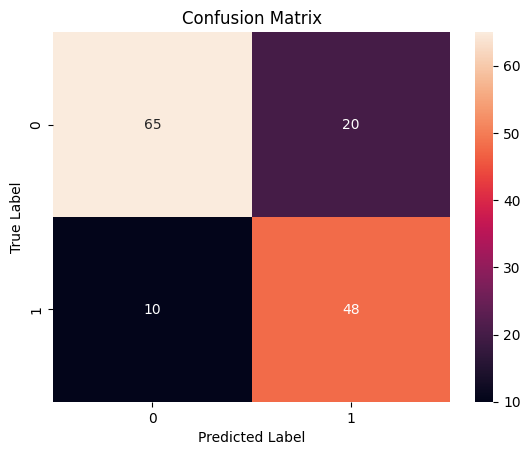

In [24]:
# TODO: Build and visualize a confusion matrix using sklearn.metrics.confusion_matrix + seaborn/matplotlib.
cm = confusion_matrix(y_test, pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


**Performance notes:**  
- TODO: Briefly discuss overall performance and the balance of precision/recall. Suggest one parameter you would tune to vary results and why (e.g., `max_depth`, `min_samples_split`, or using probabilities with a threshold).

At max depth = 6 and min samples = 2, i am getting good generalization results. i tried with max depth = 5 and it had way lower recall. chaning min samples from 2 to 5 didnt really show much big of a difference at max depth 4-6. also i noticed that at max depth = 4 the tree was better generalized then at max depth = 5 but better again at max depth = 6. overall accuracy is good and precision and recall are decently similar (in my case recall is better then precision). i think that max depth impacts the tree more. so tuning it is important. for now i think 6 is a really good depth for my model.

#### **Assume** that your model gives an Accuracy of ~60%. What could be the most probable explanation for this specific number? Make sure to use code to explain your answer. 

In [25]:
# Hint: Inspect class imbalance in the training set.
# that probably means that the model is just giving 0 for all outputs, meaning saying all are dead which is incorrect but also shows that there is an imbalance in the dataset. more 0s and less 1s.
# also that means the model hasnt learnt anything at all.
print(339/(230+339))
y_train.value_counts()

0.5957820738137083


survived
0    339
1    230
Name: count, dtype: int64

## Part H - Different Max depth values 

After seeing how our initial model performed with a default value of Max depth , we will now explore different Max depth values. This step will help us find the best Max depth setting to improve our model's ability to predict accurately

- Gather the accuracy for each `max_depth` value on the test set and compare them. Show these comparisons in a graph to easily see which `max_depth` value leads to the best predictions. This will help us choose the best k value for our model.


In [26]:
# TODO: Loop over multiple max_depth values, train fresh trees, and store their accuracies.
# This helps visualize how model complexity affects generalization.
acc = []
depths = range(0,25)
for i in depths:
    tr = DecisionTree(i,2)
    tr.fit(combined)
    pred = tr.predict(X_test)
    acc.append(accuracy_score(y_test, pred))

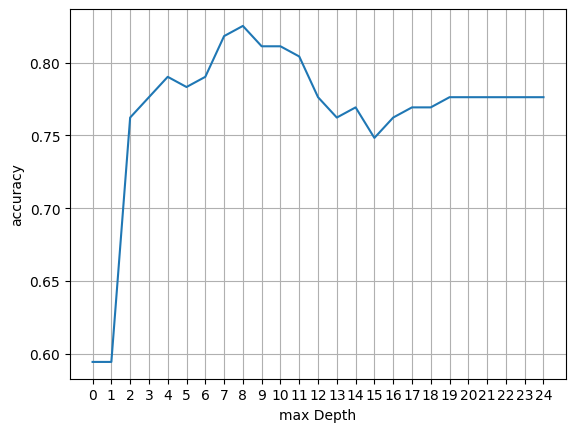

In [27]:
# TODO: Plot accuracy vs. max_depth using matplotlib so you can discuss the trend.
plt.figure()
plt.plot(depths, acc)
plt.xlabel("max Depth")
plt.ylabel("accuracy")
plt.xticks(depths)
plt.grid(True)
plt.show()

### What are you able to determine through the trend obtained for accuracy as depth varies?

_Summarize your conclusion (e.g., overfitting/underfitting) after inspecting the accuracy-vs-depth plot._

As depth increased, the overall accuracy also increased, it peaked around depth 8. this shows that shallow trees underfit and as depth increases they can capture more of the complexities of the dataset. after depth 9 the accuracy starts dropping this can be due to overfitting and learning the noise instead of generalizing. where the depth flattens out at 19 that means that the model cant learn anymore from the dataset. overall theres tradeoffs between complexity and memorizing. less depth we had underfitting and higher depth we have overfitting.
